In [12]:
#import pygeomhpges as hpges
from __future__ import annotations
import sys

import units
import logging

import awkward as ak
import numba
import numpy as np
import pint
import pyg4ometry
import pygeomhpges
from lgdo import VectorOfVectors
from lgdo.types import LGDO
from numpy.typing import NDArray
from scipy import stats

from reboost.units import ureg as u
import surface

import numpy as np
import matplotlib.pyplot as plt

In [55]:
# plot carica iniziale
def plot_initial_charge(charge, dx):
    x = np.arange(len(charge)) * dx

    plt.figure()
    plt.plot(x, charge)
    plt.title("Initial charge distribution")
    plt.xlabel("Position (µm)")
    plt.ylabel("Charge")
    plt.show()


# plot : evoluzione della diffusione
def plot_diffusion_evolution(init_charge, nsteps, factor, recomb=0, recomb_depth=600, dx=10):

    charge = init_charge.copy()

    snapshots = []

    for i in range(nsteps):
        charge, _ = surface._advance_diffusion(
            charge,
            factor=factor,
            recomb=recomb,
            recomb_depth=recomb_depth,
            delta_x=dx
        )

        # salva alcuni step
        if i in [0, 5, 20, 50, 200]:
            snapshots.append(charge.copy())

    x = np.arange(len(init_charge)) * dx

    plt.figure()
    for i, s in enumerate(snapshots):
        plt.plot(x, s, label=f"t={i}")

    plt.title("Diffusion evolution")
    plt.xlabel("Position (µm)")
    plt.ylabel("Charge")
    plt.legend()
    plt.show()

# heatmap della difffusione
def plot_diffusion_heatmap(init_charge, nsteps, factor, recomb=0, recomb_depth=600, dx=10):

    charge = init_charge.copy()
    history = []

    for i in range(nsteps):
        charge, _ = surface._advance_diffusion(
            charge,
            factor=factor,
            recomb=recomb,
            recomb_depth=recomb_depth,
            delta_x=dx
        )
        history.append(charge.copy())

    history = np.array(history)

    plt.figure()
    plt.imshow(history.T, aspect='auto', origin='lower')
    plt.colorbar(label="Charge")
    plt.title("Charge diffusion (time vs position)")
    plt.xlabel("Time step")
    plt.ylabel("Position bin")
    plt.show()

# zoom ricombinazione
def plot_diffusion_heatmap(init_charge, nsteps, factor, recomb=0, recomb_depth=600, dx=10):

    charge = init_charge.copy()
    history = []

    for i in range(nsteps):
        charge, _ = surface._advance_diffusion(
            charge,
            factor=factor,
            recomb=recomb,
            recomb_depth=recomb_depth,
            delta_x=dx
        )
        history.append(charge.copy())

    history = np.array(history)

    plt.figure()
    plt.imshow(history.T, aspect='auto', origin='lower')
    plt.colorbar(label="Charge")
    plt.title("Charge diffusion (time vs position)")
    plt.xlabel("Time step")
    plt.ylabel("Position bin")
    plt.show()



# corrected charges
def plot_collected_charge(init_charge, nsteps, factor, recomb=0, recomb_depth=600, dx=10):

    collected = surface._compute_diffusion_impl(
        init_charge,
        nsteps=nsteps,
        factor=factor,
        recomb=recomb,
        recomb_depth=recomb_depth,
        delta_x=dx
    )

    plt.figure()
    plt.plot(collected)
    plt.title("Collected charge (detector signal)")
    plt.xlabel("Time step")
    plt.ylabel("Charge collected")
    plt.show()

def plot_recombination(init_charge, recomb, recomb_depth, dx, nsteps, factor):

    charge = init_charge.copy()
    total_charge = []

    for i in range(nsteps):
        charge, _ = surface._advance_diffusion(
            charge,
            factor=factor,
            recomb=recomb,
            recomb_depth=recomb_depth,
            delta_x=dx
        )
        total_charge.append(np.sum(charge))

    plt.figure()
    plt.plot(total_charge)
    plt.title("Total charge vs time (recombination effect)")
    plt.xlabel("Time step")
    plt.ylabel("Total charge")
    plt.show()
# corrente
def plot_current_signal(init_charge, nsteps, factor, recomb=0, recomb_depth=600, dx=10):

    collected = surface._compute_diffusion_impl(
        init_charge,
        nsteps=nsteps,
        factor=factor,
        recomb=recomb,
        recomb_depth=recomb_depth,
        delta_x=dx
    )

    current = np.diff(collected)

    plt.figure()
    plt.plot(current)
    plt.title("Current signal (dQ/dt)")
    plt.xlabel("Time step")
    plt.ylabel("Current")
    plt.show()

# surface response
def plot_surface_response(fccd, init, **kwargs):

    resp = surface.get_surface_response(fccd, init=init, **kwargs)

    plt.figure()
    plt.plot(resp)
    plt.title(f"Surface response (init={init} µm)")
    plt.xlabel("Time step")
    plt.ylabel("Cumulative charge")
    plt.show()

#SURFACE RESPONSE LIBRARY (HEATMAP)
def plot_surface_library(fccd, dist_step, **kwargs):

    lib = surface.get_surface_library(fccd, dist_step, **kwargs)

    plt.figure()
    plt.imshow(lib, aspect='auto', origin='lower')
    plt.colorbar(label="Charge")
    plt.title("Surface response library")
    plt.xlabel("Depth index")
    plt.ylabel("Time step")
    plt.show()





In [36]:
init_charge = np.array([0, 0, 10, 0, 0])

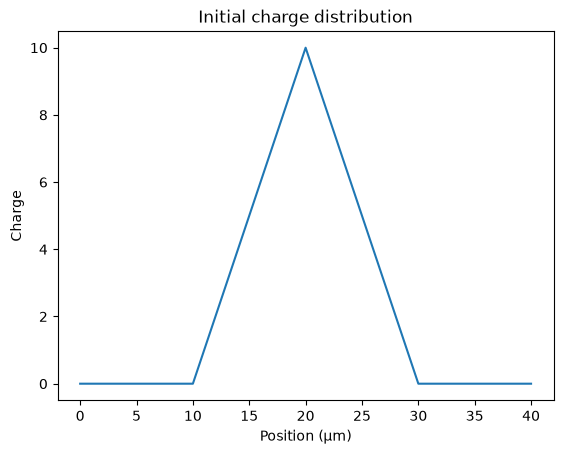

In [37]:
plot_initial_charge(init_charge, dx=10)


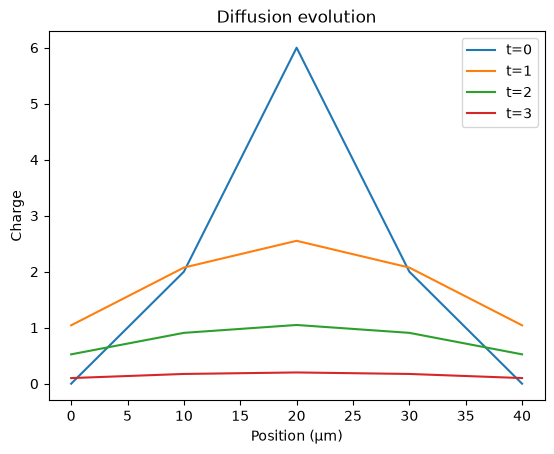

In [38]:

plot_diffusion_evolution(init_charge, 200, factor=0.2)

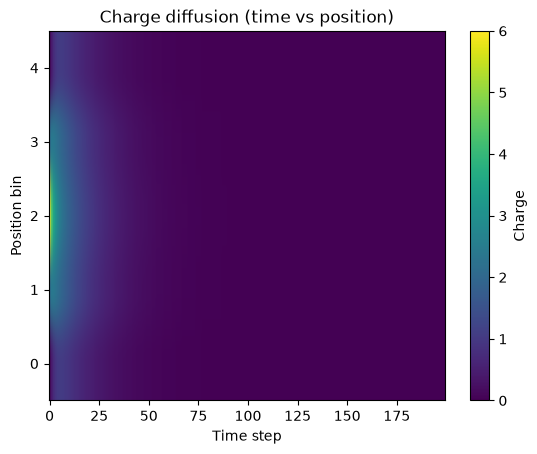

In [39]:
plot_diffusion_heatmap(init_charge, 200, factor=0.2)

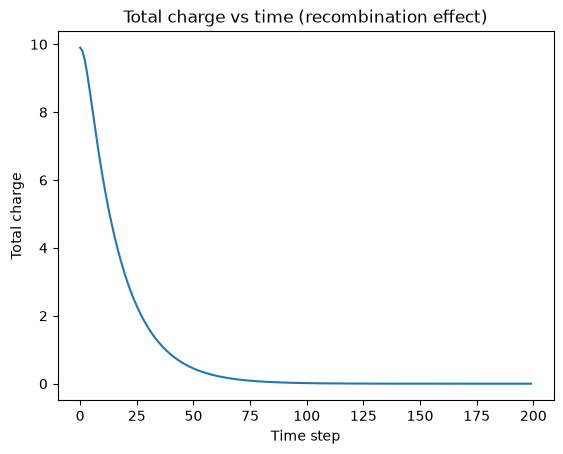

In [40]:
plot_recombination(init_charge, 0.01, 50, dx=10, nsteps=200, factor=0.2)


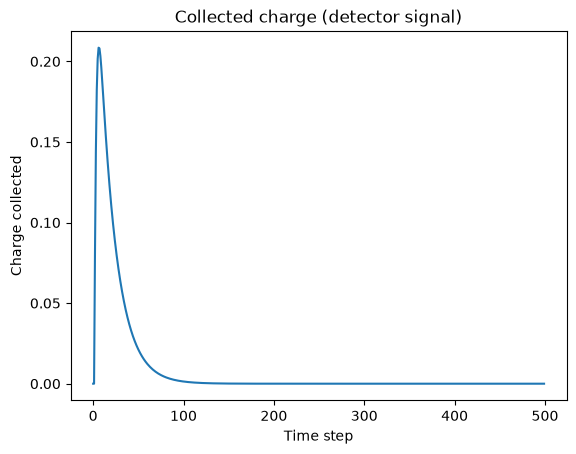

In [42]:
init_charge = np.array([0, 0, 10, 0, 0], dtype=np.float64)

plot_collected_charge(init_charge, 500, factor=0.2)


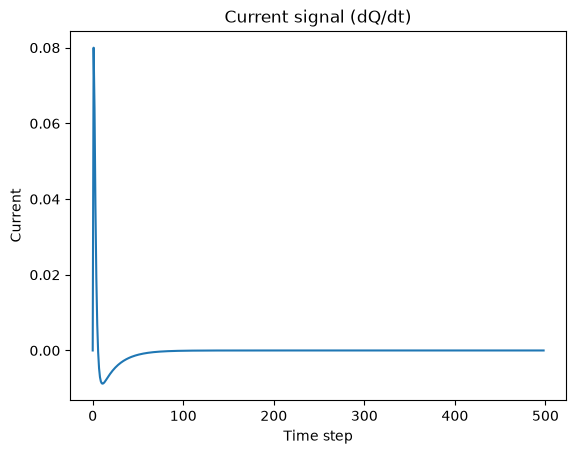

In [43]:
plot_current_signal(init_charge, 500, factor=0.2)

In [ ]:
cmap = plt.colormaps["inferno"]
fccd_values = np.linspace(600, 800, 200)
color  = cmap(np.linspace(0.2, 0.8, len(fccd_values)))
plt.figure()

for (i,fccd) in enumerate(fccd_values):
    resp = surface.get_surface_response(fccd=fccd, init=200)
    plt.plot(resp, color = color[i], alpha=0.3)  # trasparenza per vedere sovrapposizione

plt.title("Surface responses for different FCCD")
plt.xlabel("Time step")
plt.ylabel("Cumulative charge")
plt.show()

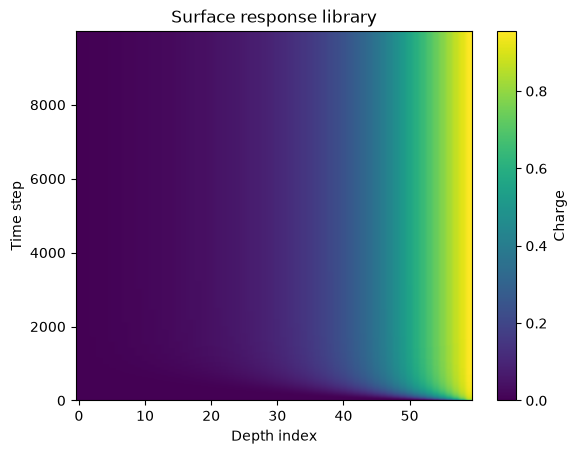

In [56]:

plot_surface_library(fccd=600, dist_step=10)
